# 🔁 Notebook 2: Push vs Pull vs Push-Pull, and Failure Detection

In notebook 1 we built **push gossip**: the node that knows something tells random peers. That's only one of three flavors used in real systems. Then we'll use gossip to solve a second classic problem: *how do nodes notice that another node has crashed?*

## Learning objectives

1. Compare **push**, **pull**, and **push-pull** gossip and see when each shines.
2. Understand **anti-entropy**: nodes reconcile state by exchanging versioned values.
3. Implement a tiny Cassandra-style failure detector using **heartbeat counters** and **generation numbers** spread by gossip.
4. See the **seed-node bootstrap** trick that prevents *logical partitions* when new nodes join.

## 🛠️ Setup

```bash
cd 02-distributed-primitives/gossip-protocol
uv sync
```

Select the `.venv` kernel (top-right of the notebook). If it's not listed, reload the VS Code window.

In [1]:
import random
import math
from dataclasses import dataclass, field
import matplotlib.pyplot as plt

random.seed(0)

## 🥊 The three flavors of gossip

All three pick `fanout` random peers per round. The difference is *who shares what*:

| Flavor | Initiator → Peer | Peer → Initiator | Best at |
| --- | --- | --- | --- |
| **Push** | sends its state | nothing | spreading **new** info fast (lots of nodes don't know yet) |
| **Pull** | asks for updates | sends what initiator is missing | mopping up the **last few stragglers** (almost everyone knows) |
| **Push-pull** | sends its state | sends back what initiator was missing | best of both — what most production systems use |

Intuition: **push** wastes effort late (already-informed nodes keep talking). **Pull** wastes effort early (almost no one has the news, so asking around fails). **Push-pull** combines them.

We'll model a single rumour spreading and compare the three on the same cluster.

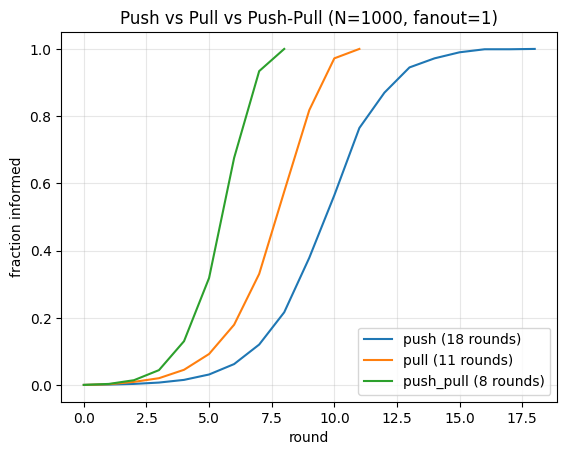

In [2]:
def simulate(mode, n=1000, fanout=3, seed=0):
    """Simulate one rumour spreading. mode in {'push','pull','push_pull'}."""
    rng = random.Random(seed)
    informed = {0}
    history = [len(informed)]
    rounds = 0
    while len(informed) < n and rounds < 200:
        rounds += 1
        new_informed = set(informed)
        # Every node gossips every round (typical real-world model).
        for src in range(n):
            for _ in range(fanout):
                peer = rng.randrange(n)
                if peer == src:
                    continue
                src_knows = src in informed
                peer_knows = peer in informed
                if mode == "push" and src_knows:
                    new_informed.add(peer)
                elif mode == "pull" and peer_knows:
                    new_informed.add(src)
                elif mode == "push_pull":
                    if src_knows or peer_knows:
                        new_informed.add(src)
                        new_informed.add(peer)
        informed = new_informed
        history.append(len(informed))
    return rounds, history

for mode in ("push", "pull", "push_pull"):
    rounds, h = simulate(mode, n=1000, fanout=1)
    plt.plot(range(len(h)), [x / 1000 for x in h], label=f"{mode} ({rounds} rounds)")
plt.xlabel("round")
plt.ylabel("fraction informed")
plt.title("Push vs Pull vs Push-Pull (N=1000, fanout=1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Things to notice in the chart:

- **Push** rockets up early but takes a long tail to catch the last ~5% of nodes.
- **Pull** is slow to start (almost no one has the rumour to give) but cleans up the tail fast.
- **Push-pull** is fastest end-to-end. This is what Cassandra, Consul/Serf and most production systems use.

## 🧹 Anti-entropy: gossiping *state*, not just rumours

So far we've gossiped a single fact ("there's news!"). In real clusters every node carries a *table* of state about every other node — things like *"node 7 is alive, last heartbeat 42, schema version v3"*.

When two nodes gossip, they exchange these tables. For each entry, they keep the **higher version**. This is called **anti-entropy** — it's how the cluster heals after failures, restarts, or message loss.

Below is a tiny Cassandra-style state record. Two pieces:

- **`generation`** — increments every time the node restarts (so a fresh start always wins over the old state).
- **`heartbeat`** — increments every gossip round while the node is alive.

Compare two records by `(generation, heartbeat)` lexicographically. Higher wins.

In [3]:
@dataclass
class NodeState:
    generation: int = 0     # bumped on restart
    heartbeat: int = 0      # bumped every tick while alive

    def version(self):
        return (self.generation, self.heartbeat)

def merge(local: NodeState, remote: NodeState) -> NodeState:
    """Anti-entropy merge: keep the entry with the highest version."""
    return remote if remote.version() > local.version() else local

a = NodeState(generation=1, heartbeat=10)
b = NodeState(generation=1, heartbeat=15)
c = NodeState(generation=2, heartbeat=0)   # restarted

print("merge(a,b) heartbeat=", merge(a, b).heartbeat, "  # b wins (higher heartbeat)")
print("merge(b,c) generation=", merge(b, c).generation, "  # c wins (restarted, higher generation)")

merge(a,b) heartbeat= 15   # b wins (higher heartbeat)
merge(b,c) generation= 2   # c wins (restarted, higher generation)


## 💀 Failure detection via gossip

Now the real trick. Each node has a **table** mapping *every other node* → its last-known `NodeState`. Every round:

1. Bump my own heartbeat.
2. Pick `fanout` random peers.
3. Exchange tables (push-pull) and merge entries with the higher version.

If a node `X` crashes, every other node will stop seeing `X`'s heartbeat go up — even indirectly via gossip. After enough rounds without progress, peers mark `X` as **suspected dead**.

(Production systems use **Phi Accrual** instead of a fixed timeout — see the `phi-accrual-failure-detection` lab in this folder.)

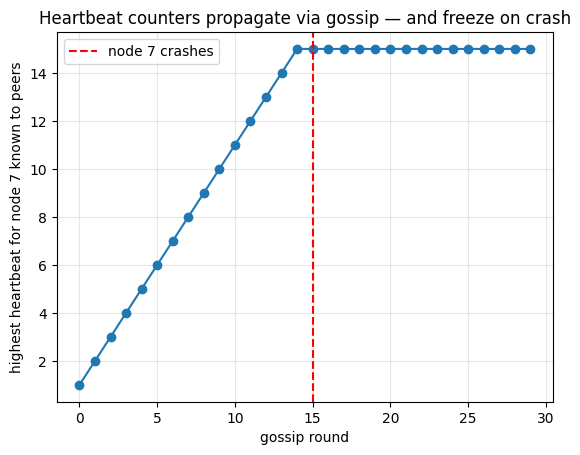

after crash, the heartbeat curve flat-lines — that's the signal peers use to suspect death.


In [4]:
@dataclass
class Node:
    node_id: int
    alive: bool = True
    # table[i] = what THIS node currently believes about node i.
    table: dict = field(default_factory=dict)

    def tick(self):
        if self.alive:
            self.table[self.node_id].heartbeat += 1

    def gossip_with(self, peer):
        """Push-pull: exchange tables, keep higher version per entry."""
        if not (self.alive and peer.alive):
            return
        for nid, remote_state in peer.table.items():
            local_state = self.table.get(nid, NodeState(-1, -1))
            self.table[nid] = merge(local_state, remote_state)
        for nid, local_state in list(self.table.items()):
            remote_state = peer.table.get(nid, NodeState(-1, -1))
            peer.table[nid] = merge(remote_state, local_state)

def make_cluster(n):
    nodes = [Node(node_id=i) for i in range(n)]
    for n_ in nodes:
        # Each node starts knowing only itself, generation 1, heartbeat 0.
        n_.table[n_.node_id] = NodeState(generation=1, heartbeat=0)
    return nodes

def run(nodes, rounds, fanout=2, kill_at=None, kill_id=None, rng=None):
    rng = rng or random.Random(1)
    n = len(nodes)
    history = []   # per round: max heartbeat seen for kill_id, across all live nodes
    for r in range(rounds):
        if kill_at is not None and r == kill_at:
            nodes[kill_id].alive = False
        for nd in nodes:
            nd.tick()
        for nd in nodes:
            if not nd.alive:
                continue
            for _ in range(fanout):
                peer = nodes[rng.randrange(n)]
                if peer.node_id != nd.node_id:
                    nd.gossip_with(peer)
        if kill_id is not None:
            seen = [nd.table.get(kill_id, NodeState(-1, -1)).heartbeat
                    for nd in nodes if nd.alive and nd.node_id != kill_id]
            history.append(max(seen) if seen else -1)
    return history

N_NODES = 50
ROUNDS = 30
KILL_AT = 15
KILL_ID = 7

nodes = make_cluster(N_NODES)
history = run(nodes, ROUNDS, fanout=2, kill_at=KILL_AT, kill_id=KILL_ID)

plt.plot(range(ROUNDS), history, marker="o")
plt.axvline(KILL_AT, color="red", linestyle="--", label=f"node {KILL_ID} crashes")
plt.xlabel("gossip round")
plt.ylabel(f"highest heartbeat for node {KILL_ID} known to peers")
plt.title("Heartbeat counters propagate via gossip — and freeze on crash")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("after crash, the heartbeat curve flat-lines — that's the signal peers use to suspect death.")

### A trivial "suspect dead" check

A super-simple detector: if a node's heartbeat hasn't increased for `K` consecutive rounds, mark it suspect. (Production code uses Phi Accrual to make this adaptive — see the related lab.)

In [5]:
K = 5
stale_for = 0
last_seen = -1
for r, hb in enumerate(history):
    if hb == last_seen:
        stale_for += 1
    else:
        stale_for = 0
        last_seen = hb
    if stale_for >= K:
        print(f"round {r}: node {KILL_ID} suspected dead (no heartbeat progress for {K} rounds)")
        break

round 19: node 7 suspected dead (no heartbeat progress for 5 rounds)


## 🌱 Seed nodes: avoiding *logical partitions*

Gossip needs at least one peer to talk to. When a brand-new node `B` boots, who does it gossip with? If admins independently start nodes `A` and `B` and neither knows the other, you get a **logical partition** — two halves of the cluster that never discover each other, even though the network is fine.

The fix is the **seed node** trick (used by Cassandra, Dynamo, Consul, …): every node ships with a hard-coded list of one or more *seed* IPs. New nodes always gossip with seeds first to learn the rest of the cluster. Seeds are not special after that — they're not a SPOF, just a meeting point.

Let's demonstrate the partition, and then the fix.

In [6]:
def discover(use_seed):
    """Two groups (A=ids 0..4, B=ids 5..9) that only know members of their own group.
    Returns whether group A discovers group B within 30 rounds."""
    rng = random.Random(2)
    nodes = make_cluster(10)
    # Each node only knows its own group at startup.
    group_a, group_b = list(range(0, 5)), list(range(5, 10))
    for i in group_a:
        nodes[i].table = {j: NodeState(1, 0) for j in group_a}
    for i in group_b:
        nodes[i].table = {j: NodeState(1, 0) for j in group_b}

    # If we use a seed, both groups also know node 0 (the seed).
    if use_seed:
        for i in group_b:
            nodes[i].table[0] = NodeState(1, 0)

    for r in range(30):
        for nd in nodes:
            nd.tick()
        for nd in nodes:
            known = [k for k in nd.table.keys() if k != nd.node_id]
            if not known:
                continue
            peer_id = rng.choice(known)
            nd.gossip_with(nodes[peer_id])
    # Did group A learn anyone from group B?
    return any(j in nodes[0].table for j in group_b)

print("without a seed -> group A discovered group B?", discover(use_seed=False))
print("with a seed    -> group A discovered group B?", discover(use_seed=True))

without a seed -> group A discovered group B? False
with a seed    -> group A discovered group B? True


## 🌍 Mapping these ideas to real systems

| Idea in this notebook | Real-world equivalent |
| --- | --- |
| `NodeState(generation, heartbeat)` | Cassandra's gossip `EndpointState` (generation + heartbeat version) |
| Push-pull merge | Cassandra `GossipDigestSyn` / `Ack` / `Ack2` 3-way handshake |
| Heartbeat freeze → suspect dead | Cassandra's `FailureDetector` (uses Phi Accrual on top) |
| Seed nodes | Cassandra `seeds:`, Consul `retry_join`, Dynamo seed list |
| Push gossip with fanout | HashiCorp Serf (SWIM) `gossip_nodes` parameter |
| Random peer selection | Redis Cluster's gossip messages on the cluster bus |

## ✅ Recap

- **Push** is fastest early; **pull** is fastest late; **push-pull** wins overall and is what production systems use.
- **Anti-entropy** is just *"keep the entry with the higher version"* applied to a state table.
- **Generation + heartbeat** versioning lets a restarted node always overwrite its old (zombie) state.
- A node is **suspected dead** when its heartbeat counter stops advancing across the cluster. Use **Phi Accrual** for an adaptive version.
- **Seed nodes** prevent logical partitions when independent admins boot nodes that don't know each other.

**Further reading:** the related labs in this folder — `heartbeat`, `phi-accrual-failure-detection`, `merkle-trees` (anti-entropy at the data level), and `vector-clocks` (versioning beyond a single counter).